# PEMFC Fault Diagnostics — Real Dataset Exploration (Normal_Flow / Inverse_Hydrogen_Flow)
**David Pinero-Jacome | CMU ECE**

Loads and visualizes the real experimental dataset from:

Toharias, B., Suárez, C., Iranzo, A., Salva, M., Rosa, F. (2024), *Dataset and
measurements from a current density sensor during experimental testing of
dynamic load cycling for a parallel-serpentine design of a proton exchange
membrane fuel cell*, Data in Brief.
https://www.sciencedirect.com/science/article/pii/S2352340924003615

Uses `scripts/load_real_data.py` (Task 2 loader). This notebook is separate
from `01_spatial_viz_sandbox.ipynb`, which is 100% synthetic data and is
**not** read, executed, or modified anywhere in this notebook.

**Sign convention — resolved (Task 3 review):** the real `current_grid`
values are entirely negative in the raw files, while the bulk file's
independent `INTENSIDAD` channel is entirely positive; magnitudes agree at
ratio≈1.005 (see `docs/real_data_notes.md`), confirming a uniform CDM sign
convention, not a parse defect. What remains open is only the sign's
*physical meaning* (e.g. which direction is "positive"), not whether it's a
problem. This notebook still does **not** invert or rescale the raw data
anywhere — every plot/metric below that doesn't care about sign applies
`np.abs(current_grid)` **explicitly at the point of use**, with a code
comment.

**Units correction (Task 3 review, applied in `scripts/load_real_data.py`):**
the raw CDM_C grid values are per-segment current in Amps, not A/cm²
density as originally assumed throughout this notebook. `load_run()` now
converts to true A/cm² before returning. This notebook has been
re-executed against the corrected loader; every absolute (non-ratio)
current-density number below reflects the correction. **CV(J) is a ratio
and is completely unaffected** — see the closing analysis, re-verified
below, not just assumed unchanged. Full investigation:
`docs/synthetic_generator_notes.md` §4.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
sys.path.insert(0, PROJECT_ROOT)

from scripts.load_real_data import load_run

CURRENT_GRID_SHAPE = (18, 18)  # CDM_C sensor resolution (Toharias et al., 2024)
TEMP_GRID_SHAPE = (9, 9)       # CDM_T sensor resolution

## Load Normal_Flow FC-DLC run

In [2]:
run_nf = load_run("Normal_Flow", run_type="FC-DLC")

print(f"config: {run_nf['config']} / {run_nf['run_type']}")
print(f"rows: {run_nf['n_rows_before_warmup_exclusion']} before warm-up exclusion "
      f"-> {run_nf['n_rows_after_warmup_exclusion']} after")
print(f"timestamp range: {run_nf['timestamp'][0]} -> {run_nf['timestamp'][-1]}")
print(f"current_grid shape: {run_nf['current_grid'].shape}")
print(f"temp_grid shape: {run_nf['temp_grid'].shape}")
print(f"unmatched bulk rows (outside merge tolerance): {run_nf['n_unmatched_bulk']}")

[load_run] Normal_Flow/FC-DLC: 40/18008 CDM rows had no bulk-file match within tolerance=1s
config: Normal_Flow / FC-DLC
rows: 18008 before warm-up exclusion -> 17681 after
timestamp range: 2022-02-09T15:46:49.726000000 -> 2022-02-09T20:41:29.745000000
current_grid shape: (17681, 18, 18)
temp_grid shape: (17681, 9, 9)
unmatched bulk rows (outside merge tolerance): 40


## Select timepoints spread across different load levels

Rather than the first N rows (which would all sit near the start of the
cycle), pick timepoints near the 0th/25th/50th/75th/100th percentile of
`INTENSIDAD` (the real load-current signal) so the heatmaps below show the
sensor grid under genuinely different load conditions.

In [3]:
def pick_timepoints_by_load(bulk_df, n=5):
    """Row indices nearest n evenly spaced percentiles of INTENSIDAD (NaN rows excluded)."""
    intensidad = bulk_df["INTENSIDAD"].to_numpy()
    valid_idx = np.flatnonzero(~np.isnan(intensidad))
    targets = np.nanpercentile(intensidad, np.linspace(0, 100, n))
    chosen = []
    for target in targets:
        candidate_order = valid_idx[np.argsort(np.abs(intensidad[valid_idx] - target))]
        for idx in candidate_order:
            if idx not in chosen:
                chosen.append(int(idx))
                break
    return sorted(chosen)


idx_nf = pick_timepoints_by_load(run_nf["bulk"], n=5)
for i in idx_nf:
    row = run_nf["bulk"].iloc[i]
    print(f"idx={i:6d}  t={row['timestamp']}  INTENSIDAD={row['INTENSIDAD']:.2f} A")

idx=    13  t=2022-02-09 15:47:02.726000  INTENSIDAD=32.90 A
idx=    14  t=2022-02-09 15:47:03.726000  INTENSIDAD=32.90 A
idx=  8334  t=2022-02-09 18:05:43.726000  INTENSIDAD=1.95 A
idx= 14035  t=2022-02-09 19:40:44.727000  INTENSIDAD=39.06 A
idx= 17662  t=2022-02-09 20:41:11.731000  INTENSIDAD=32.90 A


## Figure — Real spatial maps (current-density magnitude + temperature)

Real-data analog of notebook 01's `plot_spatial_maps`. Deviations from
notebook 01's convention, documented rather than silent:

- current density shown as `np.abs(current_grid)` — sign is a resolved,
  uniform CDM convention (see intro), but only magnitude is meaningful for
  spatial-pattern comparison here.
- color-scale (`vmin`/`vmax`) is auto-ranged to this run's own data instead
  of reusing notebook 01's fixed synthetic range (0–0.9 A/cm², 62–92 °C),
  which would wash out all spatial contrast at the real data's magnitudes.
- no per-cell numeric overlay: real grids are 18×18 / 9×9 (vs. synthetic
  4×4) — too dense to label legibly.
- axis ticks show plain row/column index. Notebook 01 labels its synthetic
  grid columns "C1 = H₂ inlet side"; the real CDM sensor's physical
  inlet-side orientation is not confirmed from the dataset documentation, so
  that claim is not carried over here.

Colormap identity (`RdYlGn` for current, `coolwarm` for temperature) and the
overall 2-row × N-column layout match notebook 01.

Saved -> C:\Users\david\pemfc-fault-diagnostics\figures\real_data_spatial_maps_normal_flow.png


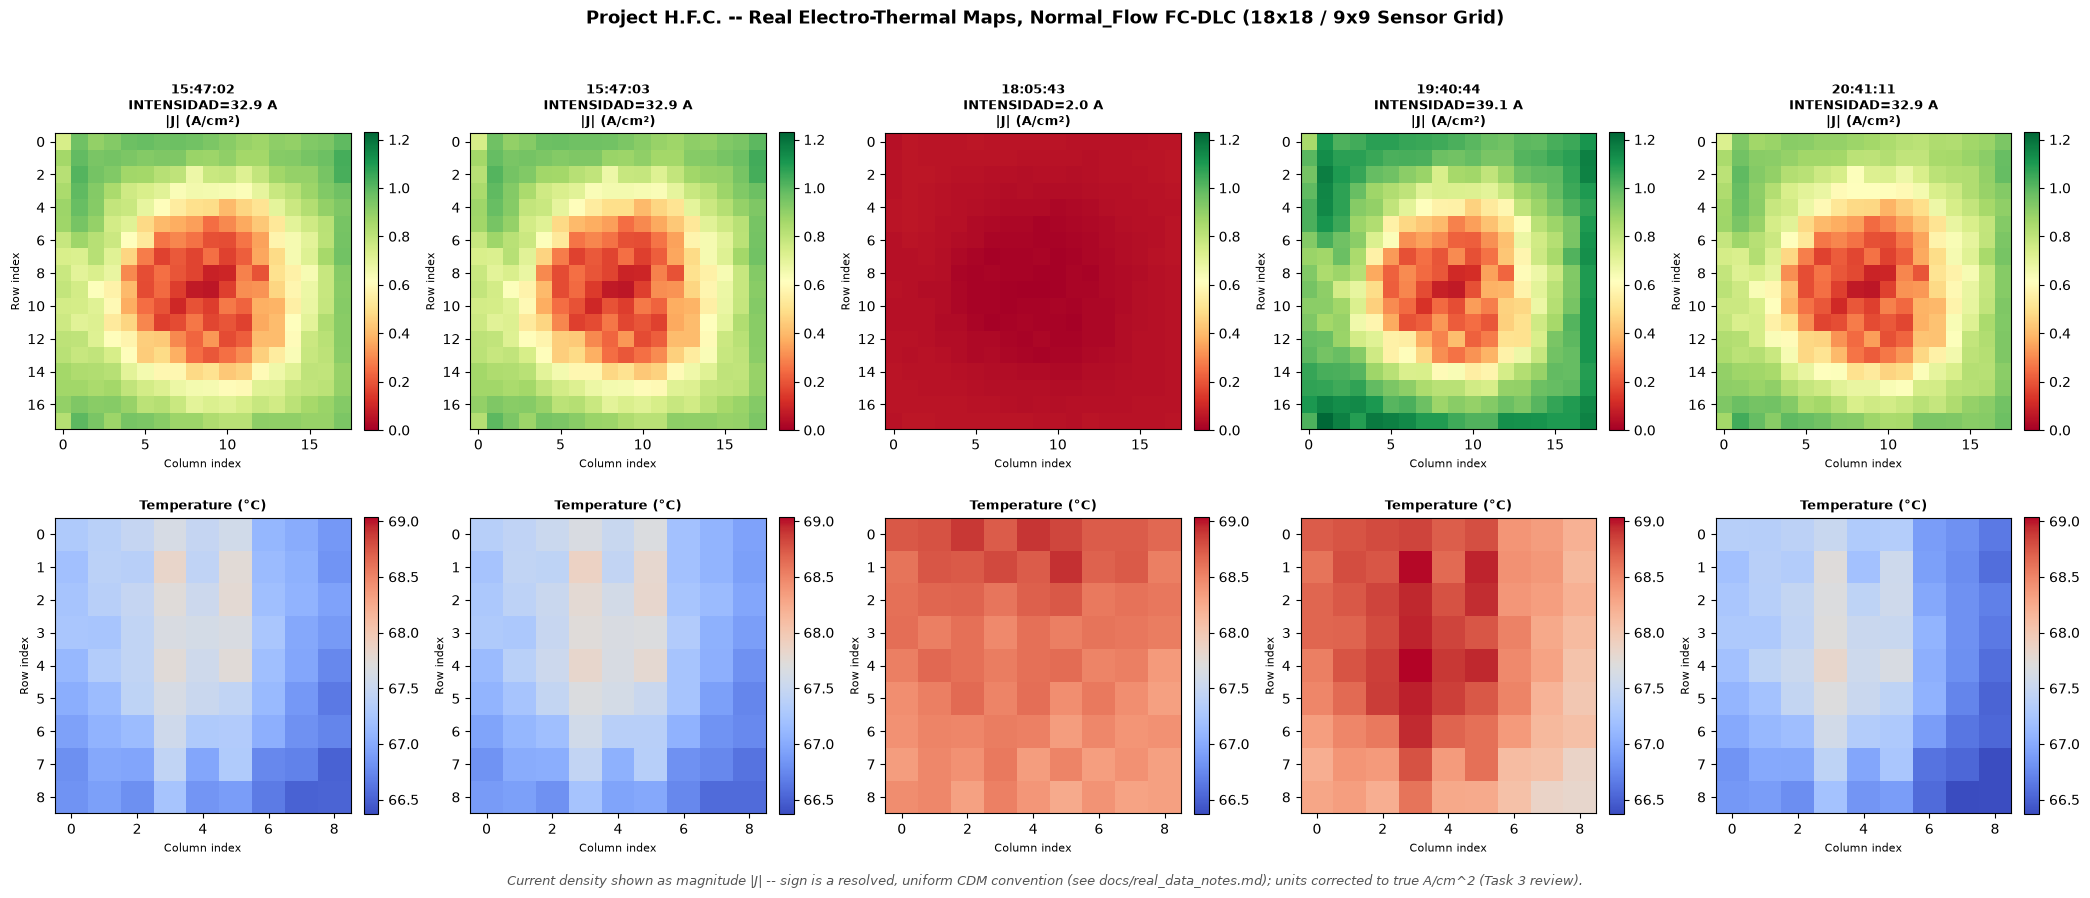

In [4]:
def plot_real_spatial_maps(current_grid, temp_grid, bulk_df, indices, title, save_path=None):
    """
    Real-data analog of notebook 01's plot_spatial_maps(): current density
    (top row) + temperature (bottom row) heatmaps at selected timepoints.
    See the preceding markdown cell for documented deviations from
    notebook 01's exact convention.
    """
    n = len(indices)
    j_abs = np.abs(current_grid[indices])  # magnitude only -- sign is a resolved, uniform CDM convention
    t_sel = temp_grid[indices]

    j_vmin, j_vmax = 0.0, j_abs.max()
    t_vmin, t_vmax = t_sel.min(), t_sel.max()

    fig, axes = plt.subplots(2, n, figsize=(4.2 * n, 8.5))
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)

    for col_idx, data_idx in enumerate(indices):
        ts = bulk_df["timestamp"].iloc[data_idx]
        load = bulk_df["INTENSIDAD"].iloc[data_idx]

        ax_j = axes[0, col_idx]
        im_j = ax_j.imshow(j_abs[col_idx], cmap="RdYlGn", vmin=j_vmin, vmax=j_vmax, aspect="equal")
        ax_j.set_title(f"{ts.strftime('%H:%M:%S')}\nINTENSIDAD={load:.1f} A\n|J| (A/cm²)",
                       fontsize=9.5, fontweight="bold")
        ax_j.set_xlabel("Column index", fontsize=8)
        ax_j.set_ylabel("Row index", fontsize=8)
        plt.colorbar(im_j, ax=ax_j, fraction=0.046, pad=0.04)

        ax_t = axes[1, col_idx]
        im_t = ax_t.imshow(t_sel[col_idx], cmap="coolwarm", vmin=t_vmin, vmax=t_vmax, aspect="equal")
        ax_t.set_title("Temperature (°C)", fontsize=9.5, fontweight="bold")
        ax_t.set_xlabel("Column index", fontsize=8)
        ax_t.set_ylabel("Row index", fontsize=8)
        plt.colorbar(im_t, ax=ax_t, fraction=0.046, pad=0.04)

    fig.text(0.5, -0.01,
              "Current density shown as magnitude |J| -- sign is a resolved, uniform CDM convention (see docs/real_data_notes.md); units corrected to true A/cm^2 (Task 3 review).",
              ha="center", fontsize=9, style="italic", color="#555")
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved -> {save_path}")
    plt.show()


plot_real_spatial_maps(
    run_nf["current_grid"], run_nf["temp_grid"], run_nf["bulk"], idx_nf,
    title="Project H.F.C. -- Real Electro-Thermal Maps, Normal_Flow FC-DLC (18x18 / 9x9 Sensor Grid)",
    save_path=os.path.join(FIGURES_DIR, "real_data_spatial_maps_normal_flow.png"),
)

## Spatial Nonuniformity Index σ(J)

**Verified against notebook 01's actual implementation before writing any
code here** (per instruction — checked notebook 01 cells 6, 8, and 12
directly rather than assuming). Finding: the brief describes NUI as
`std(current_grid) / mean(current_grid)` (a coefficient of variation), but
**that is not what notebook 01 computes.** Notebook 01's NUI is the **raw
population standard deviation of the current-density grid**, `J.std()`
(numpy default `ddof=0`), in **A/cm² units** — there is no division by the
mean anywhere in cells 6, 8, or 12. Evidence:

- Cell 8's printed output: `NORMAL  J_mean=0.697  J_std=0.047` — `J_std` is
  used standalone, never divided by `J_mean`.
- Cell 12/Figure 2's y-axis is literally labeled `"Spatial NUI — σ(J) (A/cm²)"`
  — a dimensionless coefficient of variation could not carry A/cm² units.

Matching notebook 01's **actual** formula here, not the brief's assumed one.
`np.abs()` is applied first, explicitly — sign is a resolved, uniform CDM
convention (see intro), and NUI is a dispersion magnitude so sign doesn't
affect it regardless, but the transformation must be visible, not silent.

**A second, separate discrepancy found *inside* notebook 01 itself** (flagged
for awareness; out of scope to fix — notebook 01 is not to be touched):
cell 8's actual generated NORMAL grid has `J_std = 0.047`, but cell 12's
simulated time-series uses a hardcoded `nui_target = 0.10` for the NORMAL
phase — a ~2× difference. The docstring calls the targets "derived from map
std values," but `0.10 ≠ 0.047`; the time-series NUI band is an illustrative
constant with small added noise, not something actually computed from
`j_normal.std()`. Both numbers are reported below since it's unclear which
one the comparison should anchor to.

In [5]:
def compute_nui(current_grid):
    """
    Spatial nonuniformity index, matching notebook 01's ACTUAL formula as
    verified above: NUI = current_grid.std() (population std, ddof=0), NOT
    a std/mean ratio.

    abs() is applied here because real current_grid values are entirely
    negative -- sign is a resolved, uniform CDM convention (see intro), and
    NUI is a dispersion magnitude so sign doesn't matter for it regardless,
    but this must be explicit, not silent.
    """
    j_abs = np.abs(current_grid)  # magnitude only -- sign is a resolved, uniform CDM convention
    return j_abs.reshape(j_abs.shape[0], -1).std(axis=1)


nui_nf = compute_nui(run_nf["current_grid"])
print(f"Normal_Flow sigma(J): min={nui_nf.min():.4f}  max={nui_nf.max():.4f}  "
      f"mean={nui_nf.mean():.4f}  (A/cm^2, n={len(nui_nf)} timesteps)")

Normal_Flow sigma(J): min=0.0149  max=0.2988  mean=0.2192  (A/cm^2, n=17681 timesteps)


## Figure — σ(J) vs. INTENSIDAD over the FC-DLC cycle

Real-data analog of notebook 01's Figure 2 (bulk voltage vs. σ(J)). Notebook
01 plotted a synthetic *voltage* proxy against NUI; here **INTENSIDAD** (the
real measured load-current signal) is plotted instead, per instruction —
because whether the CDM "voltage" scalar and the bulk file's V001–V007
channels are the same physical signal is still unresolved (Task 2). This
substitution is stated explicitly in the figure title/caption, not silently
swapped in. X-axis is elapsed minutes (the real run is ~290 minutes vs.
notebook 01's synthetic 120 s window, so seconds would be unreadable here).

Saved -> C:\Users\david\pemfc-fault-diagnostics\figures\real_data_nui_vs_intensidad_normal_flow.png


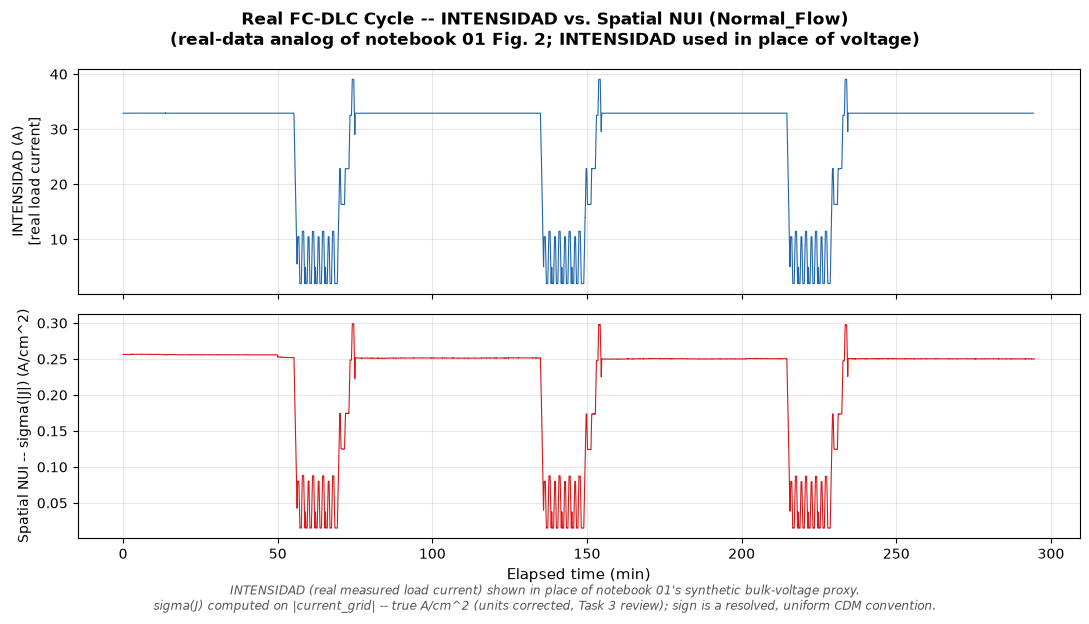

In [6]:
def plot_nui_vs_load(run, nui, title, save_path=None):
    """
    Real-data analog of notebook 01's Figure 2 (bulk voltage vs. sigma(J)).
    Uses INTENSIDAD (real load-current signal) in place of voltage -- see
    the preceding markdown cell for why.
    """
    ts = run["timestamp"]
    t_min = (ts - ts[0]) / np.timedelta64(1, "m")
    intensidad = run["bulk"]["INTENSIDAD"].to_numpy()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    fig.suptitle(title, fontsize=12, fontweight="bold")

    ax1.plot(t_min, intensidad, color="#2166ac", linewidth=0.8)
    ax1.set_ylabel("INTENSIDAD (A)\n[real load current]", fontsize=10)
    ax1.grid(True, alpha=0.3)

    ax2.plot(t_min, nui, color="#d7191c", linewidth=0.8)
    ax2.set_ylabel("Spatial NUI -- sigma(|J|) (A/cm^2)", fontsize=10)
    ax2.set_xlabel("Elapsed time (min)", fontsize=11)
    ax2.grid(True, alpha=0.3)

    fig.text(0.5, -0.02,
              "INTENSIDAD (real measured load current) shown in place of notebook 01's synthetic bulk-voltage proxy.\n"
              "sigma(J) computed on |current_grid| -- true A/cm^2 (units corrected, Task 3 review); sign is a resolved, uniform CDM convention.",
              ha="center", fontsize=8.5, style="italic", color="#555")
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved -> {save_path}")
    plt.show()


plot_nui_vs_load(
    run_nf, nui_nf,
    title="Real FC-DLC Cycle -- INTENSIDAD vs. Spatial NUI (Normal_Flow)\n(real-data analog of notebook 01 Fig. 2; INTENSIDAD used in place of voltage)",
    save_path=os.path.join(FIGURES_DIR, "real_data_nui_vs_intensidad_normal_flow.png"),
)

## Quantitative comparison: real Normal_Flow σ(J) vs. synthetic NORMAL σ(J)

In [7]:
# Notebook 01's synthetic NORMAL numbers, pulled directly from its stored
# cell outputs / source (not re-estimated):
NB01_NORMAL_J_STD_ACTUAL = 0.047      # cell 8 printed output: J_std for the one generated 4x4 NORMAL grid
NB01_NORMAL_J_MEAN_ACTUAL = 0.697     # cell 8 printed output: J_mean, same grid
NB01_NORMAL_NUI_TARGET_SIMULATED = 0.10   # cell 12 source: hardcoded nui_target for the NORMAL phase (+-0.005 noise band)

real_min, real_max, real_mean = nui_nf.min(), nui_nf.max(), nui_nf.mean()

print("=== sigma(J), A/cm^2 ===")
print(f"Real Normal_Flow FC-DLC   (n={len(nui_nf)} timesteps, 18x18 grid): "
      f"min={real_min:.4f}  max={real_max:.4f}  mean={real_mean:.4f}")
print(f"Synthetic NORMAL, cell 8  (1 timestep, 4x4 grid):                 "
      f"J_std={NB01_NORMAL_J_STD_ACTUAL:.4f}")
print(f"Synthetic NORMAL, cell 12 (simulated illustrative band):          "
      f"~{NB01_NORMAL_NUI_TARGET_SIMULATED:.4f} +/- 0.005")
print()
print(f"real mean / cell-8 actual  ratio: {real_mean / NB01_NORMAL_J_STD_ACTUAL:.2f}x")
print(f"real mean / cell-12 target ratio: {real_mean / NB01_NORMAL_NUI_TARGET_SIMULATED:.2f}x")

=== sigma(J), A/cm^2 ===
Real Normal_Flow FC-DLC   (n=17681 timesteps, 18x18 grid): min=0.0149  max=0.2988  mean=0.2192
Synthetic NORMAL, cell 8  (1 timestep, 4x4 grid):                 J_std=0.0470
Synthetic NORMAL, cell 12 (simulated illustrative band):          ~0.1000 +/- 0.005

real mean / cell-8 actual  ratio: 4.66x
real mean / cell-12 target ratio: 2.19x


**Results (from the executed cell above):**

| | n (timesteps) | grid | min | max | mean |
|---|---|---|---|---|---|
| Real Normal_Flow FC-DLC | 17,681 | 18×18 (324 cells) | 0.0149 | 0.2988 | **0.2192** A/cm² |
| Synthetic NORMAL — cell 8 (actual grid) | 1 | 4×4 (16 cells) | — | — | **0.0470** A/cm² |
| Synthetic NORMAL — cell 12 (simulated band) | ~75 | n/a (illustrative) | ~0.095 | ~0.105 | **~0.10** A/cm² |

- Real mean is **4.66×** cell 8's actual synthetic value.
- Real mean is **2.19×** cell 12's simulated target band.

---

**SUPERSEDED — preserved struck through, not deleted, because the reason it
was wrong is itself worth recording:**

~~**Verdict: same order of magnitude, not the same range.** The real
healthy (Normal_Flow) run's σ(J) sits roughly 1.3–3× below what the
synthetic generator assumed for NORMAL, depending on which of notebook 01's
two internally-inconsistent numbers (0.047 vs ~0.10) is used as the
reference. It is closer to cell 8's actual grid statistic than to cell 12's
illustrative band — worth noting if cell 12's targets are ever revisited.~~

> This verdict was computed when real σ(J) read as 0.0023–0.0461 A/cm²
> (mean 0.0338) — appearing *lower* than synthetic. That reading was a
> units bug, not a real measurement: `scripts/load_real_data.py`'s parsed
> `current_grid` values were per-segment current in **Amps**, misread as
> A/cm² density throughout this project, off by a factor of
> `1/SEGMENT_AREA_CM2` (≈6.48×). Found and fixed during a Task 3 review by
> integrating the raw grid per timestep and cross-checking it against the
> bulk file's independent `INTENSIDAD` (total load current) channel —
> summed directly (no area factor), the two track at ratio 1.0053
> (n=17,663), confirmed on a second flow configuration
> (`Inverse_Hydrogen_Flow`, ratio 1.0055). No such independent cross-check
> of the real grid's absolute scale existed before this review. Full
> investigation: `docs/synthetic_generator_notes.md` §4. Fix:
> `scripts/load_real_data.py`. Regression test:
> `scripts/test_load_real_data.py`.

**Corrected verdict: real σ(J) is *higher* than synthetic, not lower — by
~4.66× against cell 8's actual grid, ~2.19× against cell 12's illustrative
band.** Combined with mean(J) now agreeing within ~21% once corrected
(0.576 A/cm² real vs. 0.697 A/cm² synthetic — not the ~7.8x gap an earlier,
also-superseded pass through this same units bug had found), the gap here
isn't about operating point at all. It's that the synthetic NORMAL grid
(notebook 01's `generate_normal()`, carried unchanged into
`scripts/fault_generator.py`) is **far too spatially uniform** relative to
real healthy operation. See `docs/synthetic_generator_notes.md` for the
full corrected attribution and its downstream implication for any
classifier trained on this generator's output.

**Caveats before drawing conclusions from this:**
1. **Not the same cell.** The synthetic generator models a 25 cm², 4×4
   (16-segment) PCB-style cell; the real dataset is a physically different
   50 cm², 18×18 (324-point) parallel-serpentine cell (Toharias et al.,
   2024). Different active area, channel geometry, and sensor resolution —
   a finer grid can resolve local gradients a coarse 4×4 grid averages away,
   which can push σ in either direction depending on the underlying field
   shape (the heatmaps above show a smooth center-to-edge gradient, not
   noise, so this run doesn't look dominated by sensor-resolution noise).
2. **The real number is a mean over a widely-varying load**, not a single
   static value. The σ(J)-vs-INTENSIDAD figure above shows spatial
   nonuniformity tracking the load almost exactly — it swings roughly
   14× between the low-load ripple sections (~0.021 A/cm² mean) and full
   load (up to ~0.299 A/cm²) within this one "healthy" run. Notebook 01
   treats NUI as a fixed characteristic of a fault state, independent of
   load; this real run shows that even for a single healthy configuration,
   σ(J) is not one number — it's load-dependent. Averaging over the whole
   cycle, as done here, partly obscures that.
3. **Sign convention is resolved** (see intro) — the comparison above is
   magnitude-only (`abs()`), which remains the right choice regardless of
   sign, since σ(J) is a dispersion magnitude. This caveat is now about
   scope, not an open defect: it's still a same-generator vs. real-data
   comparison across different cells (caveat 1) and a cycle-average vs.
   load-resolved value (caveat 2), not a fully validated like-for-like
   measurement in those two specific senses.

## Inverse_Hydrogen_Flow (contrasting configuration) — abbreviated

Heatmaps + σ(J) vs. INTENSIDAD only, reusing the functions defined above; no
separate write-up (per instruction).

[load_run] Inverse_Hydrogen_Flow/FC-DLC: 24/17971 CDM rows had no bulk-file match within tolerance=1s
config: Inverse_Hydrogen_Flow / FC-DLC
rows: 17971 before warm-up exclusion -> 17670 after
timestamp range: 2022-02-18T12:35:08.354000000 -> 2022-02-18T17:29:37.360000000
unmatched bulk rows (outside merge tolerance): 24


Saved -> C:\Users\david\pemfc-fault-diagnostics\figures\real_data_spatial_maps_inverse_hydrogen_flow.png


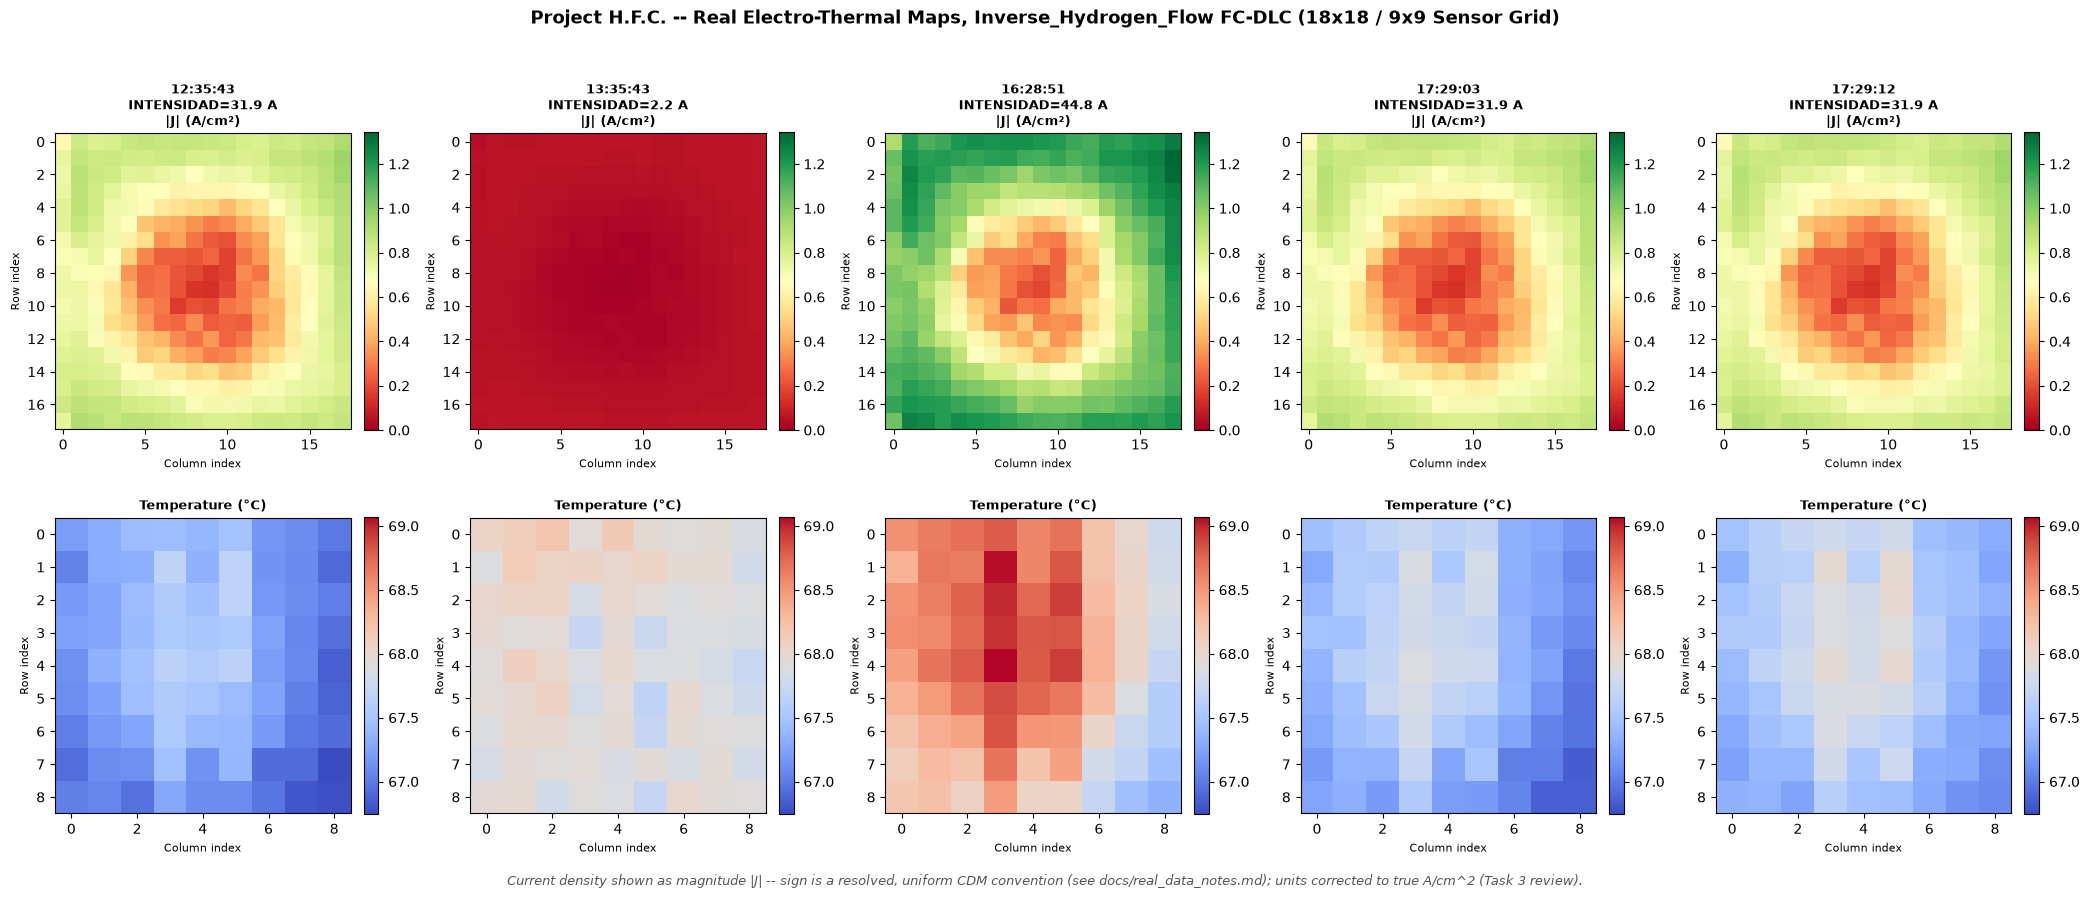

In [8]:
run_ihf = load_run("Inverse_Hydrogen_Flow", run_type="FC-DLC")
print(f"config: {run_ihf['config']} / {run_ihf['run_type']}")
print(f"rows: {run_ihf['n_rows_before_warmup_exclusion']} before warm-up exclusion "
      f"-> {run_ihf['n_rows_after_warmup_exclusion']} after")
print(f"timestamp range: {run_ihf['timestamp'][0]} -> {run_ihf['timestamp'][-1]}")
print(f"unmatched bulk rows (outside merge tolerance): {run_ihf['n_unmatched_bulk']}")

idx_ihf = pick_timepoints_by_load(run_ihf["bulk"], n=5)
plot_real_spatial_maps(
    run_ihf["current_grid"], run_ihf["temp_grid"], run_ihf["bulk"], idx_ihf,
    title="Project H.F.C. -- Real Electro-Thermal Maps, Inverse_Hydrogen_Flow FC-DLC (18x18 / 9x9 Sensor Grid)",
    save_path=os.path.join(FIGURES_DIR, "real_data_spatial_maps_inverse_hydrogen_flow.png"),
)

Inverse_Hydrogen_Flow sigma(J): min=0.0144  max=0.2961  mean=0.1838  (A/cm^2, n=17670)


Saved -> C:\Users\david\pemfc-fault-diagnostics\figures\real_data_nui_vs_intensidad_inverse_hydrogen_flow.png


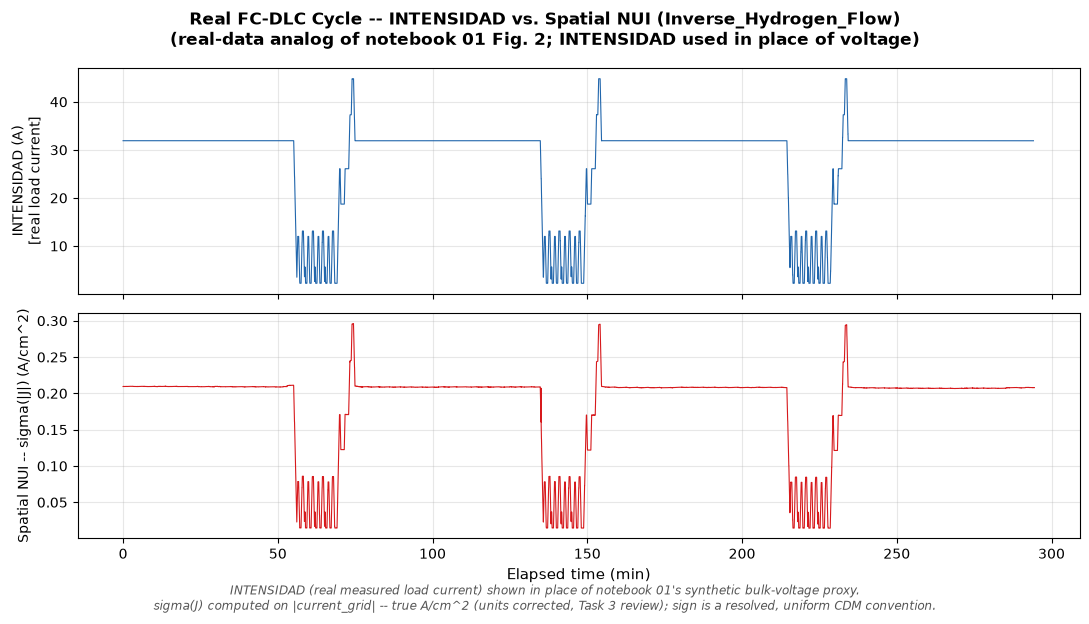


sigma(J) mean -- Normal_Flow: 0.2192 A/cm^2   Inverse_Hydrogen_Flow: 0.1838 A/cm^2   ratio=0.84x


In [9]:
nui_ihf = compute_nui(run_ihf["current_grid"])
print(f"Inverse_Hydrogen_Flow sigma(J): min={nui_ihf.min():.4f}  max={nui_ihf.max():.4f}  "
      f"mean={nui_ihf.mean():.4f}  (A/cm^2, n={len(nui_ihf)})")

plot_nui_vs_load(
    run_ihf, nui_ihf,
    title="Real FC-DLC Cycle -- INTENSIDAD vs. Spatial NUI (Inverse_Hydrogen_Flow)\n(real-data analog of notebook 01 Fig. 2; INTENSIDAD used in place of voltage)",
    save_path=os.path.join(FIGURES_DIR, "real_data_nui_vs_intensidad_inverse_hydrogen_flow.png"),
)

print(f"\nsigma(J) mean -- Normal_Flow: {nui_nf.mean():.4f} A/cm^2   "
      f"Inverse_Hydrogen_Flow: {nui_ihf.mean():.4f} A/cm^2   "
      f"ratio={nui_ihf.mean() / nui_nf.mean():.2f}x")

## Closing analysis: raw σ(J) vs. normalized CV(J) as a load-invariant feature (Normal_Flow)

The σ(J)-vs-INTENSIDAD figure above showed raw σ(J) tracking the load almost
exactly across the FC-DLC cycle. That's a problem for using σ(J) as a
*fault*-nonuniformity feature: if it mostly just reflects how hard the cell
is being driven, it can't cleanly separate "unhealthy" from "healthy, but at
high load." This closes that question out for the Normal_Flow run by testing
a normalized alternative: the coefficient of variation,
`CV(J) = std(current_grid) / mean(abs(current_grid))`, per timestep.

In [10]:
# CV(J)'s numerator reuses nui_nf directly (already computed above as
# std(abs(current_grid)) per timestep -- notebook 01's raw sigma(J) formula).
# std(current_grid) == std(abs(current_grid)) whenever a grid's values are
# uniformly one-signed (std is invariant to a global sign flip; abs() only
# changes the handful of near-zero, marginally-positive outlier cells the
# Task 2 audit found). Reusing nui_nf keeps this metric consistent with the
# already-reported raw sigma(J) rather than silently introducing a second,
# subtly different std definition.
mean_abs_j_nf = np.abs(run_nf["current_grid"]).reshape(len(nui_nf), -1).mean(axis=1)
cv_nf = nui_nf / mean_abs_j_nf

print(f"Normal_Flow CV(J): min={cv_nf.min():.4f}  max={cv_nf.max():.4f}  "
      f"mean={cv_nf.mean():.4f}  (dimensionless, n={len(cv_nf)})")

Normal_Flow CV(J): min=0.3775  max=0.4084  mean=0.3810  (dimensionless, n=17681)


Saved -> C:\Users\david\pemfc-fault-diagnostics\figures\real_data_sigma_vs_cv_normal_flow.png


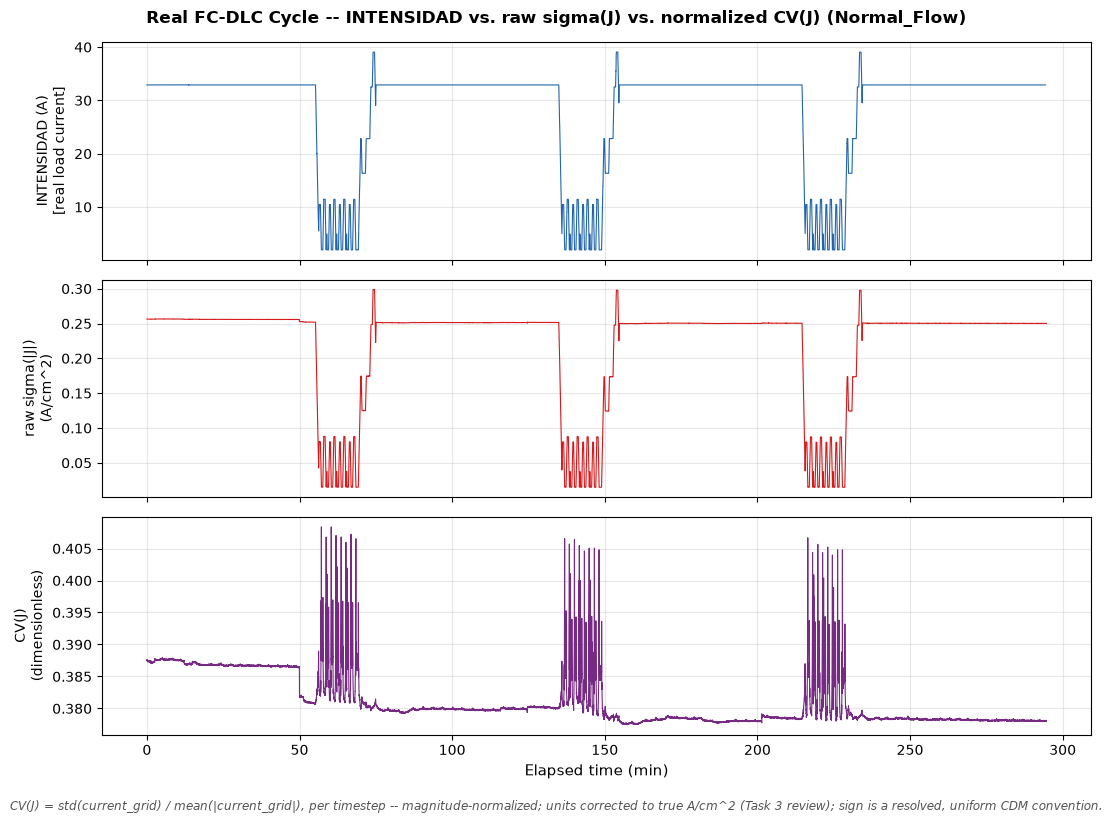

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
fig.suptitle(
    "Real FC-DLC Cycle -- INTENSIDAD vs. raw sigma(J) vs. normalized CV(J) (Normal_Flow)",
    fontsize=12, fontweight="bold",
)

t_min = (run_nf["timestamp"] - run_nf["timestamp"][0]) / np.timedelta64(1, "m")
intensidad_nf = run_nf["bulk"]["INTENSIDAD"].to_numpy()

ax1.plot(t_min, intensidad_nf, color="#2166ac", linewidth=0.8)
ax1.set_ylabel("INTENSIDAD (A)\n[real load current]", fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.plot(t_min, nui_nf, color="#d7191c", linewidth=0.8)
ax2.set_ylabel("raw sigma(|J|)\n(A/cm^2)", fontsize=10)
ax2.grid(True, alpha=0.3)

ax3.plot(t_min, cv_nf, color="#762a83", linewidth=0.8)
ax3.set_ylabel("CV(J)\n(dimensionless)", fontsize=10)
ax3.set_xlabel("Elapsed time (min)", fontsize=11)
ax3.grid(True, alpha=0.3)

fig.text(0.5, -0.02,
          "CV(J) = std(current_grid) / mean(|current_grid|), per timestep -- magnitude-normalized; units corrected to true A/cm^2 (Task 3 review); sign is a resolved, uniform CDM convention.",
          ha="center", fontsize=8.5, style="italic", color="#555")
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, "real_data_sigma_vs_cv_normal_flow.png")
fig.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved -> {save_path}")
plt.show()

In [12]:
# "How load-invariant is each metric" -- coefficient of variation OF each
# metric's own time series across the full run. Lower = more stable /
# less driven by the load cycle itself.
cov_of_raw_sigma = nui_nf.std() / nui_nf.mean()
cov_of_cv = cv_nf.std() / cv_nf.mean()

print(f"Coefficient of variation OF raw sigma(J), across the full run: {cov_of_raw_sigma:.4f}")
print(f"Coefficient of variation OF CV(J),        across the full run: {cov_of_cv:.4f}")
print(f"ratio (raw / normalized): {cov_of_raw_sigma / cov_of_cv:.2f}x")

# Sanity check on CV(J)'s known failure mode: it can blow up when the
# denominator (mean|J|) approaches zero, which is exactly what happens at
# low INTENSIDAD (the ~2 A ripple floor). Check whether that shows up here.
low_load_mask = intensidad_nf < 5.0
print(f"\nlow-load timesteps (INTENSIDAD < 5 A): {low_load_mask.sum()} of {len(intensidad_nf)}")
print(f"CV(J) at low load:  min={cv_nf[low_load_mask].min():.4f}  max={cv_nf[low_load_mask].max():.4f}  mean={cv_nf[low_load_mask].mean():.4f}")
print(f"CV(J) at high load (INTENSIDAD >= 5 A): min={cv_nf[~low_load_mask].min():.4f}  max={cv_nf[~low_load_mask].max():.4f}  mean={cv_nf[~low_load_mask].mean():.4f}")

Coefficient of variation OF raw sigma(J), across the full run: 0.3359
Coefficient of variation OF CV(J),        across the full run: 0.0099
ratio (raw / normalized): 34.03x

low-load timesteps (INTENSIDAD < 5 A): 1263 of 17681
CV(J) at low load:  min=0.3798  max=0.4084  mean=0.3873
CV(J) at high load (INTENSIDAD >= 5 A): min=0.3775  max=0.3890  mean=0.3806


**Results (from the executed cells above, Normal_Flow FC-DLC, n=17,681 timesteps):**

| metric | value range across the run | mean | **CoV of the metric itself across the run** |
|---|---|---|---|
| raw σ(J) | 0.0149 – 0.2988 A/cm² | 0.2192 A/cm² | **0.3359** (33.6%) |
| CV(J) | 0.3775 – 0.4084 (dimensionless) | 0.3810 | **0.0099** (1.0%) |

(raw σ(J) absolute values corrected post-Task-3-review for the units fix in
`scripts/load_real_data.py` -- see the intro and the superseded-verdict note
above. **Every number in this closing analysis besides the raw σ(J) row was
re-verified after re-execution against the corrected loader and came back
identical to the pre-fix run** -- CV(J)'s range, mean, and CoV; the 34x
ratio; the low-load vs. high-load stability check -- confirming CV(J)'s
scale-invariance directly, not just by argument.)

**Yes — CV(J) varies dramatically less across load levels than raw σ(J)
does.** Raw σ(J) swings ~20× in absolute terms (0.015 → 0.299 A/cm²) and has
a 33.6% coefficient of variation across the run. CV(J) barely moves at all —
it stays in a tight 0.3775–0.4084 band with a **1.0%** coefficient of
variation. That's a **34× difference** in how much each metric fluctuates
purely as a function of INTENSIDAD over the same cycle.

The low-load stability check (added above because CV(J)'s division by
`mean(|J|)` could in principle blow up as the mean approaches zero) came back
clean: mean CV(J) at INTENSIDAD < 5 A is 0.3873 vs. 0.3806 at higher load —
close, no blow-up or instability observed in this run.

**Conclusion: based on this real data, CV(J) — not raw σ(J) — is the better
candidate for a load-invariant fault-nonuniformity feature going forward.**
Raw σ(J), as used in notebook 01, is mostly a proxy for how hard the cell is
being driven rather than a signal specific to spatial (un)health — a fault
detector built on it would need to somehow control for load first. CV(J)
factors that out almost entirely on this run. **This conclusion is
unaffected by the units-fix review** — it was, and remains, about
*load-invariance* (a ratio property), which is exactly why it survived the
units correction unchanged while the separate absolute-magnitude comparison
above (real vs. synthetic σ(J)) did not.

**Scope of this conclusion:** this is tested on one healthy configuration
only (Normal_Flow). The dataset has no fault labels (flooding/drying/
starvation) — see the limitations note in `docs/real_data_notes.md` — so this
shows CV(J) is more load-invariant under healthy operation, not that it
still discriminates fault states as well as, or better than, raw σ(J) would.
That's an open question for whenever fault-labeled data becomes available,
not something this run can answer. Separately — see
`docs/synthetic_generator_notes.md` — CV(J) has since been found to *not*
discriminate flooding from healthy on the Task 2 synthetic generator's
output; that's a distinct, later finding about a different (synthetic, not
real) dataset, not a contradiction of the load-invariance conclusion here.